# Gate #3 — 2D Detector Recall vs Keyframe Pedestrian Boxes

Visualizes `data/processed/detector2d_recall_report.json` from
`scripts/eval_detector2d_recall.py`. A COCO-trained YOLO ("person" class) is run on each
sequence's **keyframe camera image** and matched by IoU to the verified 2D pedestrian boxes.

Why this is a cleaner experiment than the 3D gate (notebook 02): the keyframe **is** a
camera frame (0 ms offset; the LiDAR gate detects on a scan 37-55 ms away), COCO "person"
generalizes far better than a nuScenes LiDAR detector, and the GT set is larger — it
includes the "2D-only" pedestrians (no `location_3d`) that the 3D pipeline skips.

In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
REPORT = ROOT / "data" / "processed" / "detector2d_recall_report.json"
report = json.loads(REPORT.read_text())
cfg, overall = report["config"], report["overall"]
print("model:", cfg["model"], "| imgsz:", cfg["imgsz"], "| conf:", cfg["conf"],
      "| IoU>=", cfg["iou_thresh"])

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

def bar_recall(ax, bins, title, xlabel, color="#3b7dd8"):
    labels = [b["bin"] for b in bins]
    recall = [b["recall"] if b["recall"] is not None else 0.0 for b in bins]
    ns = [b["n_gt"] for b in bins]
    bars = ax.bar(labels, recall, color=color, edgecolor="#1f4e8c")
    for bar, r, n in zip(bars, recall, ns):
        ax.text(bar.get_x() + bar.get_width() / 2, r + 0.02, f"{r:.2f}\nn={n}",
                ha="center", va="bottom", fontsize=8)
    ax.set_ylim(0, 1.1); ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel("recall")
    ax.tick_params(axis="x", rotation=30)

model: yolo11x.pt | imgsz: 2560 | conf: 0.1 | IoU>= 0.5


## 1. Headline metrics

Note the precision here vs the 3D gate (notebook 02): YOLO is far cleaner (fewer false
positives) as well as higher-recall.

sequences : 358
GT peds   : 2159
recall    : 0.629   (TP=1358  FN=801)
precision : 0.644   (FP=749)


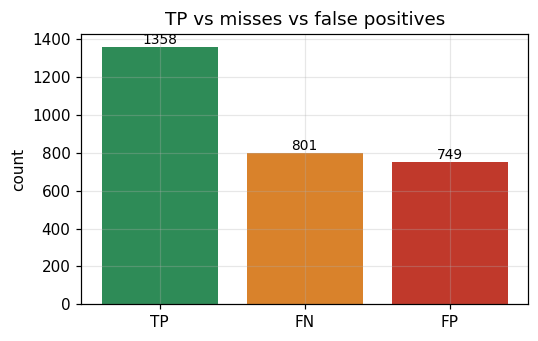

In [2]:
o = overall
print(f"sequences : {o['n_sequences']}")
print(f"GT peds   : {o['n_gt']}")
print(f"recall    : {o['recall']:.3f}   (TP={o['tp']}  FN={o['fn']})")
print(f"precision : {o['precision']:.3f}   (FP={o['fp']})")

fig, ax = plt.subplots(figsize=(5, 3.2))
ax.bar(["TP", "FN", "FP"], [o["tp"], o["fn"], o["fp"]], color=["#2e8b57", "#d9822b", "#c0392b"])
ax.set_title("TP vs misses vs false positives"); ax.set_ylabel("count")
for i, v in enumerate([o["tp"], o["fn"], o["fp"]]):
    ax.text(i, v, str(v), ha="center", va="bottom", fontsize=9)
plt.tight_layout(); plt.show()

## 2. Recall by box height (px) and by occlusion

Box height is the image-plane proxy for range/size. **Occlusion is the dominant failure
axis** — and it is a single-frame limitation the tracker recovers across frames.

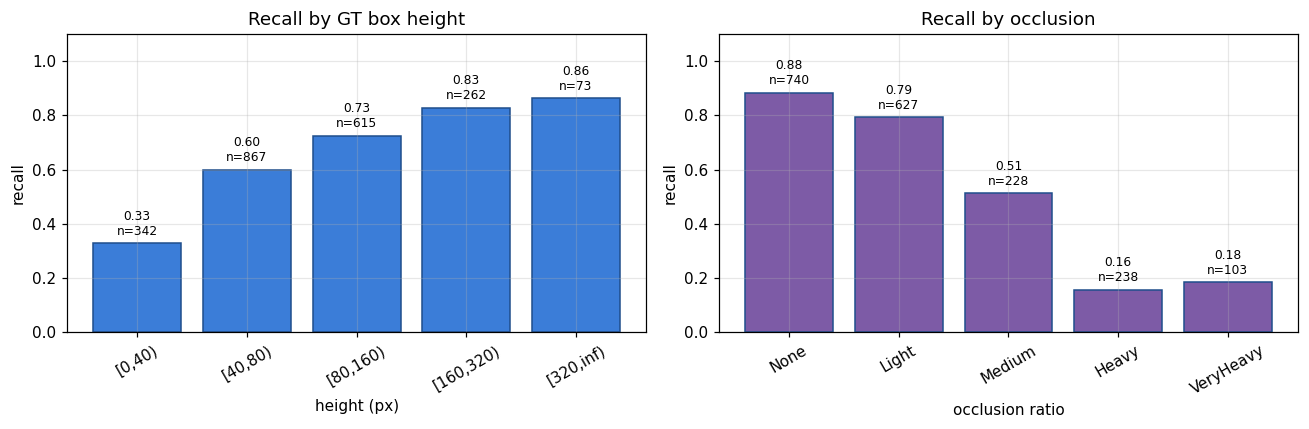

In [3]:
occ = report["by_occlusion"]
# order occlusion bins from least to most occluded where possible
order = ["None", "Light", "Medium", "Heavy", "VeryHeavy"]
occ_bins = [{"bin": k, "recall": occ[k]["recall"], "n_gt": occ[k]["n_gt"]}
            for k in order if k in occ]
occ_bins += [{"bin": k, "recall": v["recall"], "n_gt": v["n_gt"]}
             for k, v in occ.items() if k not in order]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
bar_recall(axes[0], report["by_height_px"], "Recall by GT box height", "height (px)")
bar_recall(axes[1], occ_bins, "Recall by occlusion", "occlusion ratio", color="#7d5ba6")
plt.tight_layout(); plt.show()

## 3. Recall by 3D availability

The "2D-only" pedestrians (no `location_3d`) are the ones the 3D pipeline cannot use at
all. They are typically smaller / more occluded, so 2D recall on them is lower — but the
2D detector at least *sees* them.

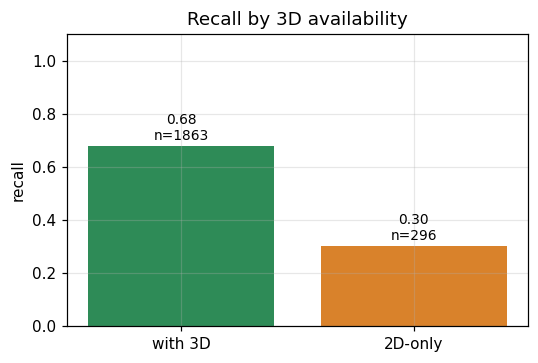

In [4]:
h = report["by_has_3d"]
labels = ["with 3D", "2D-only"]
vals = [h["with_3d"]["recall"], h["2d_only"]["recall"]]
ns = [h["with_3d"]["n_gt"], h["2d_only"]["n_gt"]]
fig, ax = plt.subplots(figsize=(5, 3.4))
bars = ax.bar(labels, vals, color=["#2e8b57", "#d9822b"])
for b, v, n in zip(bars, vals, ns):
    ax.text(b.get_x() + b.get_width()/2, v + 0.02, f"{v:.2f}\nn={n}", ha="center", fontsize=9)
ax.set_ylim(0, 1.1); ax.set_ylabel("recall"); ax.set_title("Recall by 3D availability")
plt.tight_layout(); plt.show()

## 4. Per-sequence recall distribution

sequences with >=1 GT: 358 | median 0.667 | mean 0.600


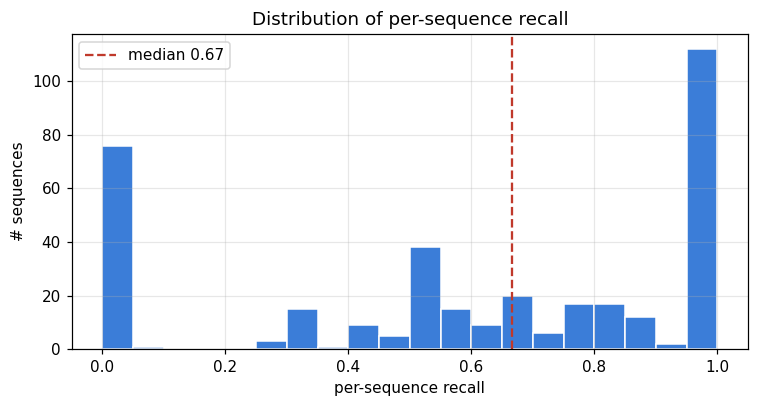

In [5]:
per_seq = np.array([s["recall"] for s in report["per_sequence"] if s["recall"] is not None])
print(f"sequences with >=1 GT: {len(per_seq)} | median {np.median(per_seq):.3f} | mean {per_seq.mean():.3f}")
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.hist(per_seq, bins=np.linspace(0, 1, 21), color="#3b7dd8", edgecolor="white")
ax.axvline(np.median(per_seq), color="#c0392b", ls="--", label=f"median {np.median(per_seq):.2f}")
ax.set_xlabel("per-sequence recall"); ax.set_ylabel("# sequences")
ax.set_title("Distribution of per-sequence recall"); ax.legend()
plt.tight_layout(); plt.show()

## 5. Visual: YOLO vs keyframe GT on the actual images

The payoff of 2D — you can *see* the failures. We re-run YOLO on a few low-recall
sequences (with at least one reasonably large pedestrian) and overlay:

* **green** &mdash; GT pedestrian YOLO recovered (IoU ≥ threshold)
* **red** &mdash; GT pedestrian missed
* **blue dashed** &mdash; YOLO "person" predictions

> Requires `ultralytics`. If unavailable, this section is skipped.

In [6]:
import sys
sys.path.insert(0, str(ROOT / "src"))
sys.path.insert(0, str(ROOT / "scripts"))

DET2D = None
try:
    from eval_detector2d_recall import make_yolo, match_greedy_iou
    from dataset.keyframe import keyframe_image_path, load_keyframe_pedestrians_2d
    DET2D = make_yolo(cfg["model"], conf=cfg["conf"], imgsz=cfg["imgsz"])
    print("YOLO ready")
except Exception as e:
    print("YOLO unavailable -> skipping visual section:", repr(e)[:160])

YOLO ready


visualizing: ['000165', '000288', '000521', '001396', '001302', '001292']


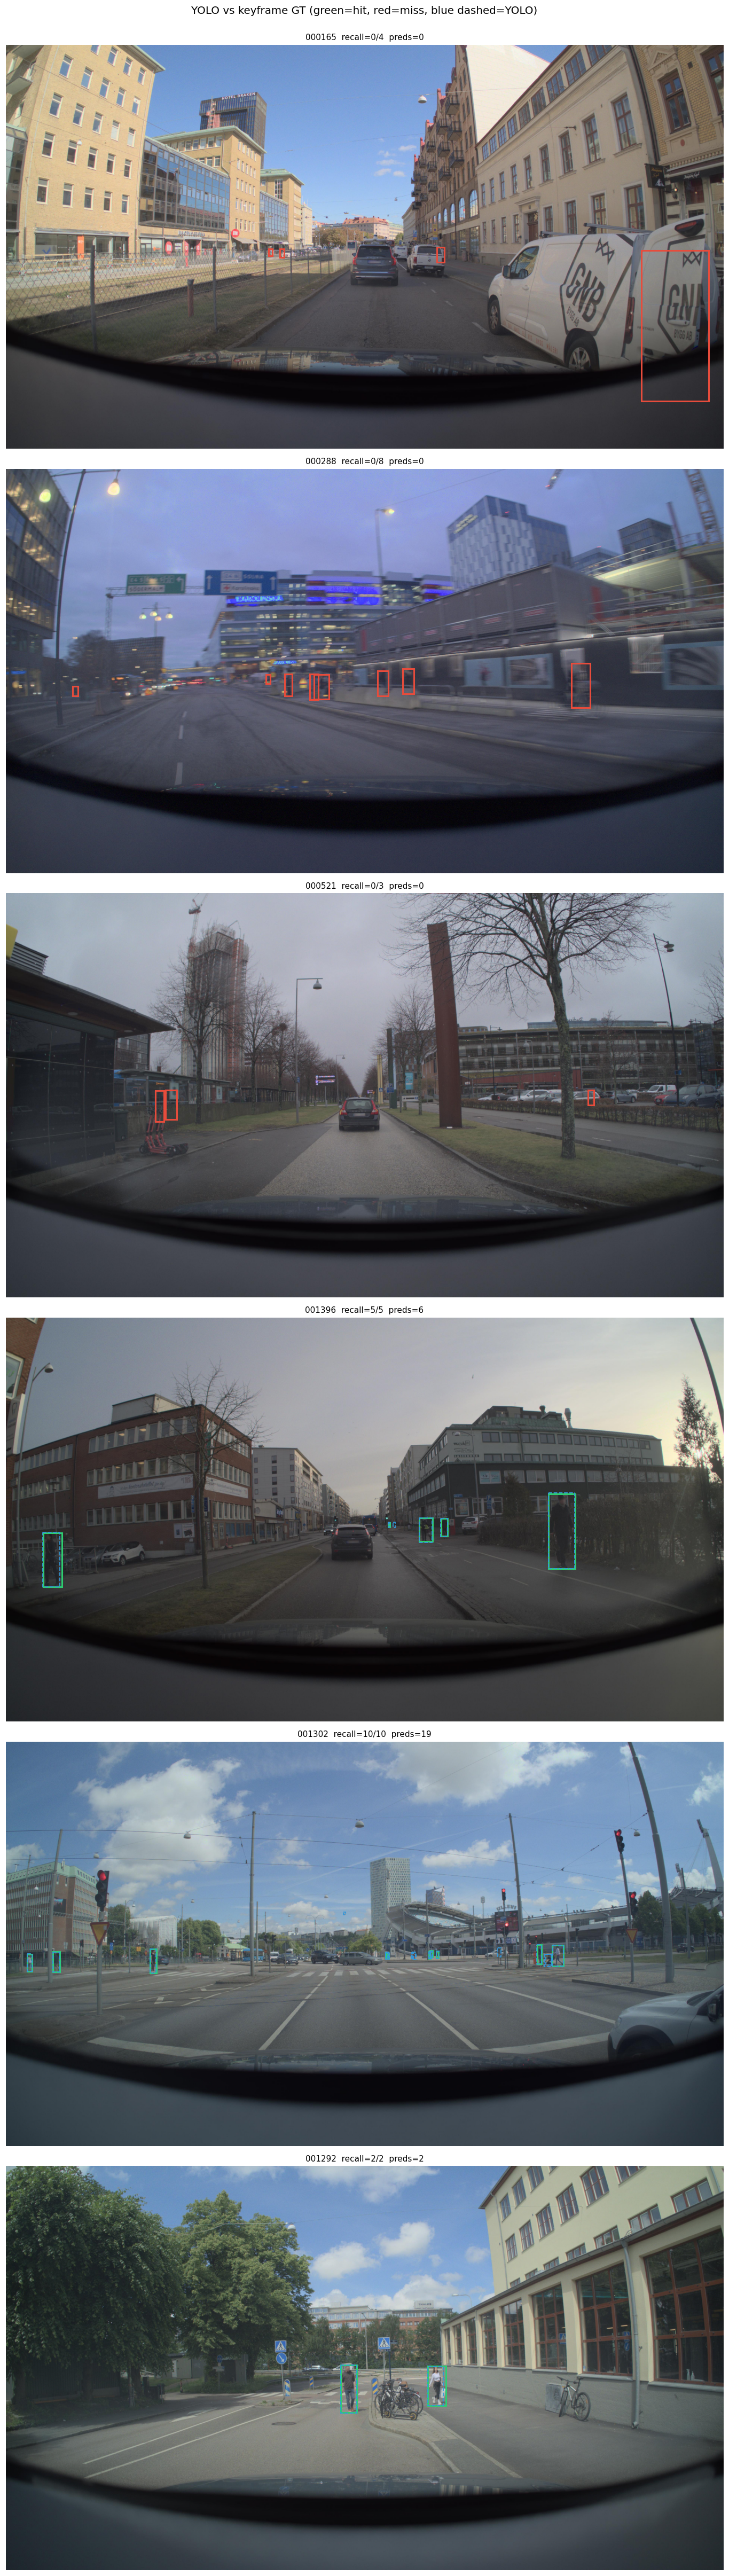

In [7]:
from matplotlib.patches import Rectangle
from PIL import Image

SEQ_DIR = ROOT / "data" / "raw" / "sequences"

def show_seq(ax, seq_id, iou_thresh=None):
    iou_thresh = iou_thresh or cfg["iou_thresh"]
    sd = SEQ_DIR / seq_id
    img_path, _ = keyframe_image_path(sd)
    gts = load_keyframe_pedestrians_2d(sd)
    preds = DET2D(img_path)
    matched = match_greedy_iou(preds, gts, iou_thresh)
    ax.imshow(np.array(Image.open(img_path)))
    for g, hit in zip(gts, matched):
        x1, y1, x2, y2 = g.xyxy
        ax.add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False,
                               edgecolor="#2ecc71" if hit else "#e74c3c", lw=2.0))
    for p in preds:
        x1, y1, x2, y2 = p.xyxy
        ax.add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False,
                               edgecolor="#3498db", ls="--", lw=1.2))
    ax.set_title(f"{seq_id}  recall={sum(matched)}/{len(gts)}  preds={len(preds)}", fontsize=10)
    ax.axis("off")

def _nearest_tall_gt(seq_id):
    gts = load_keyframe_pedestrians_2d(SEQ_DIR / seq_id)
    return max((g.height for g in gts), default=0.0)

if DET2D is not None:
    scored = sorted([s for s in report["per_sequence"]
                     if s.get("recall") is not None and s["n_gt"] >= 2],
                    key=lambda s: s["recall"])
    # mix of BAD (low-recall) + GOOD (high-recall) scenes, each with a large visible pedestrian
    tall = [s for s in scored if _nearest_tall_gt(s["seq_id"]) >= 120]
    seqs = [s["seq_id"] for s in tall[:3]] + [s["seq_id"] for s in reversed(tall)][:3]
    # seqs = ["000007"]   # <- edit to inspect specific sequences
    print("visualizing:", seqs)
    fig, axes = plt.subplots(len(seqs), 1, figsize=(13, 7.3 * len(seqs)))
    axes = np.atleast_1d(axes)
    for ax, sq in zip(axes, seqs):
        show_seq(ax, sq)
    fig.suptitle("YOLO vs keyframe GT (green=hit, red=miss, blue dashed=YOLO)", fontsize=13, y=1.0)
    plt.tight_layout(); plt.show()

**Reading the images:** the green boxes are the clear, close pedestrians YOLO gets
right; reds clustered at bus stops / crowds are heavy-occlusion misses; small reds are
distant pedestrians shrunk below YOLO's effective resolution. None of these are frame /
coordinate problems — they are the expected hard cases, and most are recoverable once
the pedestrian is tracked across the full clip rather than judged on one frame.